# LimSim Rolling Visualization Demo

This advanced example generates compact GIF demos for the LimSim-style rolling behavior model. It uses WOMD interactive validation scenarios, selects vehicle-only RoIs, runs repeated interaction planning updates, and renders selected high-level actions with simulated short-horizon trajectories.

The ego-centered GIF is saved to `tests/runtime/limsim_behavior_demo.gif`; the fixed-RoI GIF is saved to `tests/runtime/limsim_behavior_fixed_roi_demo.gif`. These files are ignored by git and are intended for local inspection or manual PR upload after review.


## 1. Imports And Repository Setup

The imports use internal LimSim rolling and evaluation modules intentionally because this notebook visualizes reproduction internals. It resolves the repository root first, then imports Tactics2D modules directly from the local checkout.

In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")


def find_repo_root(start):
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "tactics2d" / "__init__.py").exists():
            return candidate
    raise RuntimeError("Cannot find the Tactics2D repository root.")


repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
runtime_dir = repo_root / "tests" / "runtime"
runtime_dir.mkdir(parents=True, exist_ok=True)

import imageio.v2 as imageio
import matplotlib.pyplot as plt
from IPython.display import Image, display
from matplotlib.patches import Circle
from shapely.geometry import Point

from tactics2d.behavior.limsim.config import LimSimConfig
from tactics2d.behavior.limsim.evaluation import dimensions_from_participants, evaluate_rolling_result
from tactics2d.behavior.limsim.rolling import LimSimRollingRunner
from tactics2d.dataset_parser import WOMDParser
from tactics2d.display.renderers import MatplotlibRenderer
from tactics2d.display.sensor import BEVCamera

## 2. Load A WOMD Interactive Scenario

This example uses a compact vehicle-only RoI from a local WOMD interactive validation shard. The selected ego-centered case starts after the scenario has already evolved for a short time, which makes the rolling behavior planning output show acceleration, deceleration, and lane-change decisions without introducing too many vehicles in the view.

In [2]:
folder = repo_root / "tactics2d" / "data" / "trajectory_sample" / "WOMD"
file_name = "uncompressed_scenario_validation_interactive_validation_interactive.tfrecord-00000-of-00150"
scenario_index = 0
frame = 1799
ego_id = 371
roi_radius = 15.0
roi_outer_radius = 27.0

if not (folder / file_name).exists():
    raise FileNotFoundError(f"WOMD sample file is missing: {folder / file_name}")

parser = WOMDParser()
participants, _ = parser.parse_trajectory(scenario_index, file=file_name, folder=str(folder))
map_ = parser.parse_map(scenario_index, file=file_name, folder=str(folder))

print("participants:", len(participants))
print("map lanes:", len(map_.lanes))


participants: 55
map lanes: 664


## 3. Run LimSim-Style Interaction Planning

The behavior model first selects RoI vehicles, filters out non-vehicle participants from interaction planning control, keeps nearby outer-band vehicles as background obstacles, builds interaction groups, searches high-level actions with MCTS, and then generates final short-horizon trajectories with the Frenet-style planner. In this rolling demo, the runner also keeps the previous round's planned trajectories and lets the next prediction step reuse the remaining trajectory when available.

In [3]:
config = LimSimConfig(horizon_steps=20, mcts_iterations=25, interaction_distance=16.0)
rolling_steps = 40
runner = LimSimRollingRunner(config)

rolling_result = runner.run(
    participants,
    map_,
    start_frame=frame,
    simulation_steps=rolling_steps,
    ego_id=ego_id,
    roi_radius=roi_radius,
    roi_outer_radius=roi_outer_radius,
)

first_result = rolling_result.results[0]
last_result = rolling_result.results[-1]
print("rolling frames:", rolling_result.frames[:5], "...", rolling_result.frames[-3:])
print("first RoI agents:", first_result.roi_agent_ids)
print("first background agents:", first_result.background_agent_ids[:10])
print("first interaction groups:", first_result.groups)
print("first selected actions:", {agent_id: action.value for agent_id, action in first_result.actions.items()})
print("last RoI agents:", last_result.roi_agent_ids)
print("last selected actions:", {agent_id: action.value for agent_id, action in last_result.actions.items()})

rolling_evaluation = evaluate_rolling_result(
    rolling_result, dimensions_from_participants(rolling_result.participants)
)
print("rolling action counts:", rolling_evaluation.action_counts)
print("rolling min distance:", round(rolling_evaluation.min_distance, 2))
print("rolling collisions:", rolling_evaluation.collision_count)
print("rolling action switches:", rolling_evaluation.action_switch_count)
print("rolling memory hits:", rolling_evaluation.memory_hit_count)


rolling frames: [1799, 1899, 1999, 2099, 2199] ... [5599, 5699, 5799]
first RoI agents: [366, 367, 371]
first background agents: [368]
first interaction groups: [[371, 366], [367]]
first selected actions: {371: 'KS', 366: 'KS', 367: 'AC'}
last RoI agents: [366, 367, 371]
last selected actions: {371: 'KS', 366: 'KS', 367: 'KS'}
rolling action counts: {'KS': 69, 'AC': 32, 'LCL': 20, 'DC': 2}
rolling min distance: 3.81
rolling collisions: 0
rolling action switches: 8
rolling memory hits: 100


The rendering follows the WOMD visualization path used elsewhere in the docs: `WOMDParser` loads the scenario, `BEVCamera` extracts render geometry, and `MatplotlibRenderer` draws each rolling simulation frame. The dashed circle marks the RoI at the current frame, colored labels show the current interaction planning action, and colored traces show the simulated path accumulated so far.


Saved rolling PDP demo to D:\tactics\tactics2d\tests\runtime\limsim_behavior_demo.gif


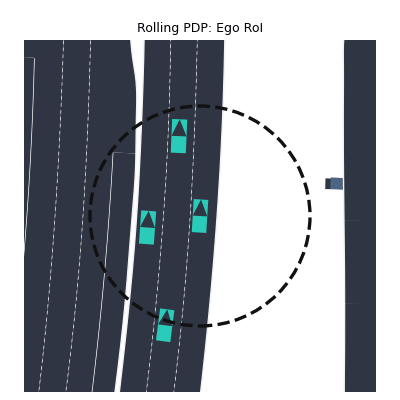

In [4]:
def action_for_frame(agent_id, render_frame):
    if render_frame <= rolling_result.frames[0]:
        return None
    step = min(max(rolling_result.frames.index(render_frame) - 1, 0), len(rolling_result.results) - 1)
    return rolling_result.results[step].actions.get(agent_id)


def roi_center_for_frame(render_frame):
    return rolling_result.participants[ego_id].trajectory.get_state(render_frame).location


def render_limsim_demo(output_path, title="Rolling interaction planning"):
    render_participants = rolling_result.participants
    render_frames = rolling_result.frames
    participant_ids = list(render_participants.keys())

    camera = BEVCamera(0, map_, perception_range=24.0)
    renderer = MatplotlibRenderer(
        resolution=(800, 800),
        auto_scale=True,
    )
    color_by_agent = {
        agent_id: plt.cm.tab10(index % 10)
        for index, agent_id in enumerate(participant_ids)
    }
    images = []

    try:
        for render_frame in render_frames:
            center = roi_center_for_frame(render_frame)
            geometry_data, _, _ = camera.update(
                render_frame,
                render_participants,
                participant_ids,
                prev_road_id_set=None,
                prev_participant_id_set=None,
                position=Point(center),
                heading=0.0,
            )
            renderer.update(geometry_data)

            roi_patch = Circle(
                center,
                roi_radius,
                fill=False,
                edgecolor="#111111",
                linewidth=2.4,
                linestyle="--",
                zorder=30,
            )
            renderer.ax.add_patch(roi_patch)

            for agent_id, participant in render_participants.items():
                color = color_by_agent[agent_id]
                trace_points = [
                    participant.trajectory.get_state(trace_frame).location
                    for trace_frame in participant.trajectory.frames
                    if trace_frame <= render_frame
                ]
                if len(trace_points) >= 2:
                    xs, ys = zip(*trace_points)
                    renderer.ax.plot(xs, ys, color=color, linewidth=2.2, alpha=0.9, zorder=35)

                action = action_for_frame(agent_id, render_frame)
                if action is None:
                    continue
                label_state = participant.trajectory.get_state(render_frame)
                x_min, x_max = renderer.ax.get_xlim()
                y_min, y_max = renderer.ax.get_ylim()
                if not (x_min <= label_state.x <= x_max and y_min <= label_state.y <= y_max):
                    continue
                label_x = min(max(label_state.x, x_min + 1.0), x_max - 1.0)
                label_y = min(max(label_state.y + 2.8, y_min + 1.0), y_max - 1.0)
                renderer.ax.text(
                    label_x,
                    label_y,
                    f"{agent_id}: {action.value}",
                    color=color,
                    fontsize=7,
                    fontweight="bold",
                    ha="center",
                    va="bottom",
                    bbox={"facecolor": "white", "edgecolor": color, "alpha": 0.85, "pad": 1.2},
                    clip_on=True,
                    zorder=50,
                )

            renderer.ax.set_title(
                title,
                fontsize=9,
            )
            images.append(renderer.save_single_frame(return_array=True))
            renderer.reset()
    finally:
        renderer.destroy()

    imageio.mimsave(output_path, images, duration=0.22)


output_path = runtime_dir / "limsim_behavior_demo.gif"
render_limsim_demo(output_path, title="Rolling interaction planning: Ego RoI")
print(f"Saved rolling behavior planning demo to {output_path}")
display(Image(filename=str(output_path)))


## 4. Run A Fixed Physical RoI Example

The previous GIF follows an ego vehicle and reselects the RoI around its current simulated state. The example below keeps the RoI center fixed at a physical location. This is useful for checking how a local road region behaves when vehicles enter, remain inside, or leave the RoI; here the fixed region highlights a compact acceleration interaction without lane changes.

fixed RoI center: (10049.56, 2977.51)
fixed rolling frames: [0, 100, 200, 300, 400] ... [2800, 2900, 3000]
fixed first RoI agents: [26, 29, 31, 33]
fixed first background agents: [32, 34]
fixed first interaction groups: [[26, 33, 31], [29]]
fixed selected actions: {26: 'AC', 33: 'AC', 31: 'AC', 29: 'AC'}
fixed action counts: {'AC': 35, 'KS': 75}
fixed min distance: 3.87
fixed collisions: 0
fixed action switches: 32
fixed memory hits: 106
Saved fixed RoI rolling PDP demo to D:\tactics\tactics2d\tests\runtime\limsim_behavior_fixed_roi_demo.gif


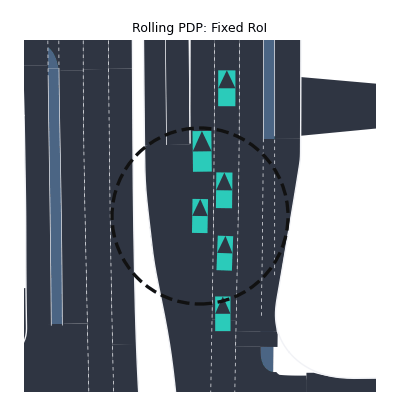

In [5]:
fixed_scenario_index = 10
fixed_frame = 0
fixed_anchor_id = 26
fixed_roi_radius = 12.0
fixed_roi_outer_radius = 21.6
fixed_rolling_steps = 30

fixed_participants, _ = parser.parse_trajectory(
    fixed_scenario_index, file=file_name, folder=str(folder)
)
fixed_map = parser.parse_map(fixed_scenario_index, file=file_name, folder=str(folder))
fixed_roi_center = fixed_participants[fixed_anchor_id].trajectory.get_state(fixed_frame).location

fixed_result = runner.run(
    fixed_participants,
    fixed_map,
    start_frame=fixed_frame,
    simulation_steps=fixed_rolling_steps,
    roi_center=fixed_roi_center,
    roi_radius=fixed_roi_radius,
    roi_outer_radius=fixed_roi_outer_radius,
)

print("fixed RoI center:", tuple(round(value, 2) for value in fixed_roi_center))
print("fixed rolling frames:", fixed_result.frames[:5], "...", fixed_result.frames[-3:])
print("fixed first RoI agents:", fixed_result.results[0].roi_agent_ids)
print("fixed first background agents:", fixed_result.results[0].background_agent_ids[:10])
print("fixed first interaction groups:", fixed_result.results[0].groups)
print(
    "fixed selected actions:",
    {agent_id: action.value for agent_id, action in fixed_result.results[0].actions.items()},
)
fixed_evaluation = evaluate_rolling_result(
    fixed_result, dimensions_from_participants(fixed_result.participants)
)
print("fixed action counts:", fixed_evaluation.action_counts)
print("fixed min distance:", round(fixed_evaluation.min_distance, 2))
print("fixed collisions:", fixed_evaluation.collision_count)
print("fixed action switches:", fixed_evaluation.action_switch_count)
print("fixed memory hits:", fixed_evaluation.memory_hit_count)

original_map = map_
original_result = rolling_result
original_roi_radius = roi_radius
original_roi_center_for_frame = roi_center_for_frame

try:
    map_ = fixed_map
    rolling_result = fixed_result
    roi_radius = fixed_roi_radius

    def roi_center_for_frame(render_frame):
        return fixed_roi_center

    fixed_output_path = runtime_dir / "limsim_behavior_fixed_roi_demo.gif"
    render_limsim_demo(fixed_output_path, title="Rolling interaction planning: Fixed RoI")
finally:
    map_ = original_map
    rolling_result = original_result
    roi_radius = original_roi_radius
    roi_center_for_frame = original_roi_center_for_frame

print(f"Saved fixed RoI rolling behavior planning demo to {fixed_output_path}")
display(Image(filename=str(fixed_output_path)))


This GIF shows the current-stage LimSim reproduction as a lightweight rolling behavior planning simulation rather than a full official LimSim simulator clone. It demonstrates repeated RoI selection, interaction grouping, MCTS high-level decisions, and first-step trajectory execution over multiple control updates. Background vehicles are advanced by a simple keep-speed lane-following rule, so long-horizon physical fidelity is still limited by the current intermediate planner.
